In [1]:
# ---- Reproducibility
import random
import torch

#seed = 1234
#random.seed(seed)
#torch.manual_seed(seed)
#if torch.cuda.is_available():
#    torch.cuda.manual_seed_all(seed)


In [2]:


# ---- Parameters
n, p = 50, 40
noise_std = 0.1

# (Optional) choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
u = torch.rand(n, dtype=torch.float64, device=device)          # length n
v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

noisy_matrix = rank_1_matrix + noise

# ---- Print (move to CPU for readability if needed)
print("Rank-1 Matrix (Outer Product):")
print(rank_1_matrix.cpu().numpy())

print("\nNoisy Matrix (with Homoscedastic Noise):")
print(noisy_matrix.cpu().numpy())


Rank-1 Matrix (Outer Product):
[[2.04952258e-01 3.98495390e-01 2.26129166e-01 ... 4.18981573e-01
  4.10882796e-01 1.54577801e-02]
 [3.35679562e-01 6.52672769e-01 3.70364007e-01 ... 6.86225916e-01
  6.72961393e-01 2.53174125e-02]
 [3.08617645e-01 6.00055397e-01 3.40505888e-01 ... 6.30903546e-01
  6.18708386e-01 2.32763656e-02]
 ...
 [1.15609951e-03 2.24784215e-03 1.27555471e-03 ... 2.36340110e-03
  2.31771733e-03 8.71946091e-05]
 [2.50475061e-01 4.87006866e-01 2.76355660e-01 ... 5.12043322e-01
  5.02145691e-01 1.88911722e-02]
 [2.92113197e-02 5.67965259e-02 3.22296101e-02 ... 5.97163691e-02
  5.85620712e-02 2.20315775e-03]]

Noisy Matrix (with Homoscedastic Noise):
[[ 0.20229312  0.45915027  0.28204923 ...  0.33990053  0.36500508
   0.0124505 ]
 [ 0.16407183  0.68308923  0.30639086 ...  0.70669455  0.60654317
   0.00553992]
 [ 0.34185574  0.52407289  0.30216499 ...  0.54355577  0.62463133
   0.03411515]
 ...
 [ 0.07048375 -0.11081906  0.08920272 ... -0.05129196  0.10646099
   0.03224741

In [3]:
import sys
import os
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

In [4]:
mycebmf=  cEBMF(data= noisy_matrix, prior_F="exp",
                prior_L="exp") 

 

In [5]:
mycebmf.initialise_factors()
print(mycebmf.L[:,1])
print(mycebmf.F[:,1])

tensor([-0.0217, -0.3195, -0.0040, -0.1452,  0.3047,  0.0495, -0.1718, -0.0615,
        -0.3020, -0.3078,  0.1181,  0.1119,  0.1102, -0.0163, -0.0846, -0.1138,
        -0.0898,  0.2324, -0.1447, -0.0932,  0.0813, -0.2444,  0.2953,  0.0708,
         0.0117,  0.1354,  0.1710,  0.1613, -0.0038,  0.1627, -0.1488,  0.0350,
         0.1931,  0.2458,  0.2131,  0.0450,  0.0524,  0.1554, -0.0895, -0.1772,
         0.3148,  0.2195, -0.0074,  0.1891,  0.1809, -0.0515, -0.2326,  0.2323,
        -0.2695, -0.2685])
tensor([ 0.2903,  0.0189,  0.2255,  0.0811,  0.0705, -0.0505, -0.2379,  0.1044,
         0.1419, -0.0081, -0.1464, -0.1485,  0.0884, -0.0526, -0.0415, -0.1741,
         0.1570, -0.2193,  0.1003, -0.3261,  0.1049,  0.1717,  0.0243, -0.0946,
         0.1167, -0.1253, -0.1110, -0.1150,  0.1718,  0.2136, -0.1337, -0.1126,
        -0.1205,  0.0631,  0.0737, -0.0333,  0.0154, -0.2370,  0.3900,  0.2083])


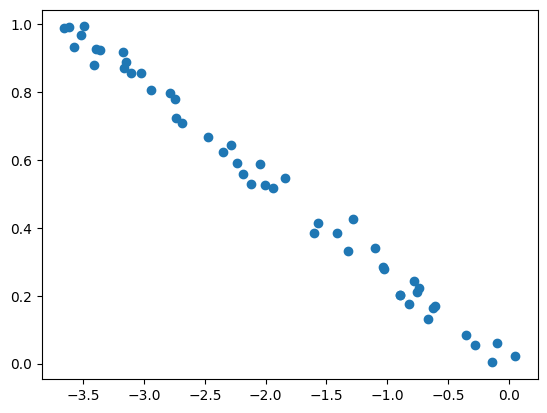

In [6]:
plt.scatter( mycebmf.L[:,0],u)

In [7]:
mycebmf.iter_once()
mycebmf._update_fitted_value()
import numpy as np
K=0
mycebmf.Y_fit 

tensor([[0.0192, 0.0297, 0.0183,  ..., 0.0320, 0.0370, 0.0036],
        [0.0735, 0.1501, 0.0744,  ..., 0.1941, 0.1687, 0.0115],
        [0.0761, 0.1401, 0.0706,  ..., 0.1709, 0.1593, 0.0128],
        ...,
        [0.2769, 0.4320, 0.2716,  ..., 0.4595, 0.5385, 0.0488],
        [0.0111, 0.0202, 0.0110,  ..., 0.0292, 0.0261, 0.0035],
        [0.0311, 0.0637, 0.0414,  ..., 0.1246, 0.1010, 0.0188]])

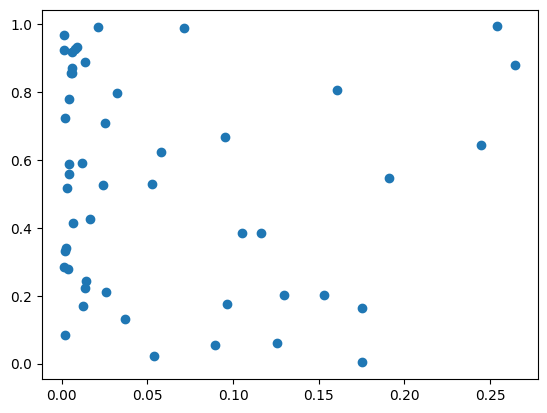

In [8]:
plt.scatter( mycebmf.L[:,0],u)

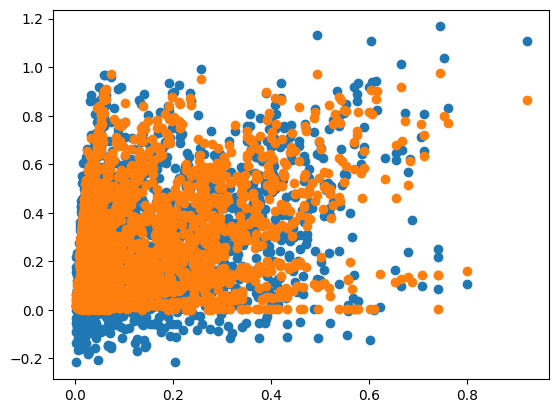

In [9]:
mycebmf.iter_once()  
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)

In [10]:
mycebmf.fit()

CEBMFResult(L=tensor([[0.2395],
        [0.3775],
        [0.3378],
        [0.2945],
        [0.3745],
        [0.2885],
        [0.1095],
        [0.3645],
        [0.1104],
        [0.3611],
        [0.2521],
        [0.0064],
        [0.2276],
        [0.0650],
        [0.1680],
        [0.3248],
        [0.3401],
        [0.0667],
        [0.2196],
        [0.3335],
        [0.0709],
        [0.1414],
        [0.2453],
        [0.2984],
        [0.1370],
        [0.3923],
        [0.1511],
        [0.2653],
        [0.0831],
        [0.0873],
        [0.2347],
        [0.3880],
        [0.0957],
        [0.1967],
        [0.0960],
        [0.2151],
        [0.0807],
        [0.0295],
        [0.3399],
        [0.2081],
        [0.3659],
        [0.3157],
        [0.0787],
        [0.0132],
        [0.1715],
        [0.3838],
        [0.1172],
        [0.0162],
        [0.2939],
        [0.0376]]), F=tensor([[0.9129],
        [1.6873],
        [0.9897],
        [1.3886],
        [1

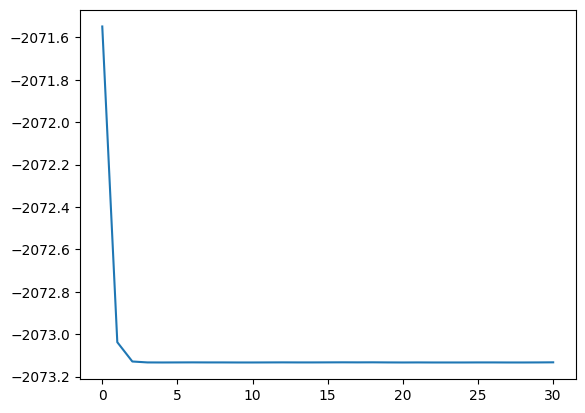

In [11]:
plt.plot(mycebmf.obj)

tensor(0.1165, dtype=torch.float64)

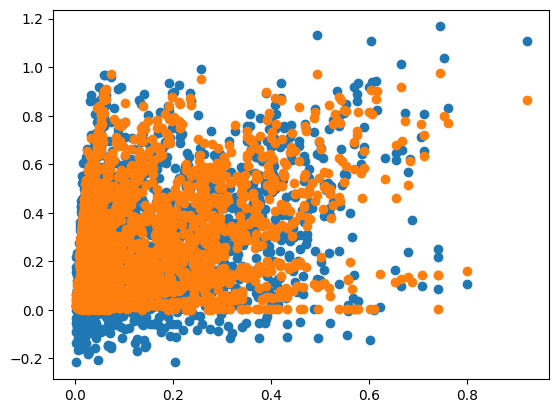

In [12]:
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)

In [ ]:
results =[]
for i in range(50):
    # Parameters
    n, p = 50, 40
    noise_std = 0.1

# (Optional) choose device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data generation (PyTorch)
# Use float64 to mirror NumPy defaults
    u = torch.rand(n, dtype=torch.float64, device=device)          # length n
    v = torch.rand(p, dtype=torch.float64, device=device)          # length p

# Rank-1 matrix via outer product
    rank_1_matrix = torch.outer(u, v)                              # (n, p)

# Homoscedastic Gaussian noise
    noise = noise_std * torch.randn(n, p, dtype=torch.float64, device=device)

    noisy_matrix = rank_1_matrix + noise

 
# Add homoscedastic Gaussian noise (constant variance across the matrix)
    mycebmf=  cEBMF(data= noisy_matrix,prior_L="exp",
                    prior_F="exp") 
    mycebmf.initialise_factors()
    mycebmf.fit()
    
    mycebmf._update_fitted_value()
    
    rr = torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)
    results.append( rr)
    res= np.asarray(results)
    print(np.mean(res ))
 

0.00030818802731455306
0.0006101715130499885


In [ ]:
i


49

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

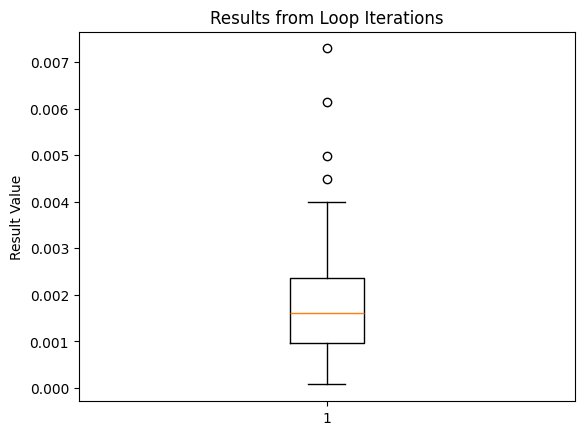

In [ ]:
plt.boxplot(results)
plt.title("Results from Loop Iterations")
plt.ylabel("Result Value")
plt.show()

In [ ]:
res= np.asarray(results)
np.mean(res )

np.float64(0.0019738271317577593)

In [ ]:
np.sqrt(np.var(res ))

np.float64(0.001492206516021613)

tensor(0.0007, dtype=torch.float64)

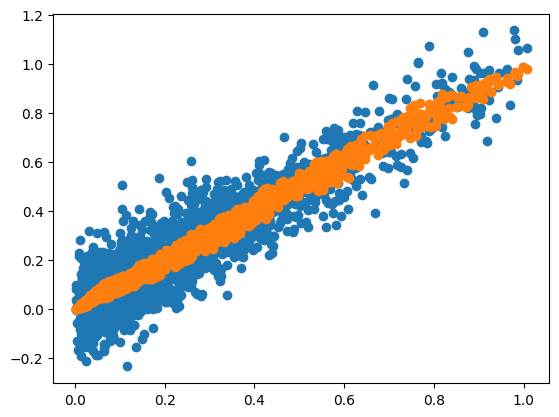

In [ ]:
mycebmf._update_fitted_value()
plt.scatter(mycebmf.Y_fit, noisy_matrix)
 
plt.scatter(mycebmf.Y_fit, rank_1_matrix)
torch.sqrt(torch.mean(mycebmf.Y_fit- rank_1_matrix)**2)